In [ ]:
import os,sys;from pathlib import Path;sys.path.insert(0, str(Path(os.getcwd()).parent/'Notebooks'))
from imports import *

Tasks from last meeting (01.03.25):

* Add 10 more shallow stations (<500m). Likely all will be Cascadia.

* Decimate the overall # of events but increase station density for those that remain (aim for a minimum of 10 per ev). Keep the reduction of events to the lower mags (<~M6.5) as much as reasonable.

* Finish out the subsequent tasks as detailed at the end of last notebook. Specifically download of the 24hr traces for NoiseCut, run the new data through NC and AtaCR and finish with the QC of processed data.

* Send you a drive w/ the AGU figs (done)

* Have a ‘semblance’ of a methods section draft written and sent to you for your flight back on the 18th.

* For Spring semester, continue meetings every Friday @2pm.


# Show old and new histograms

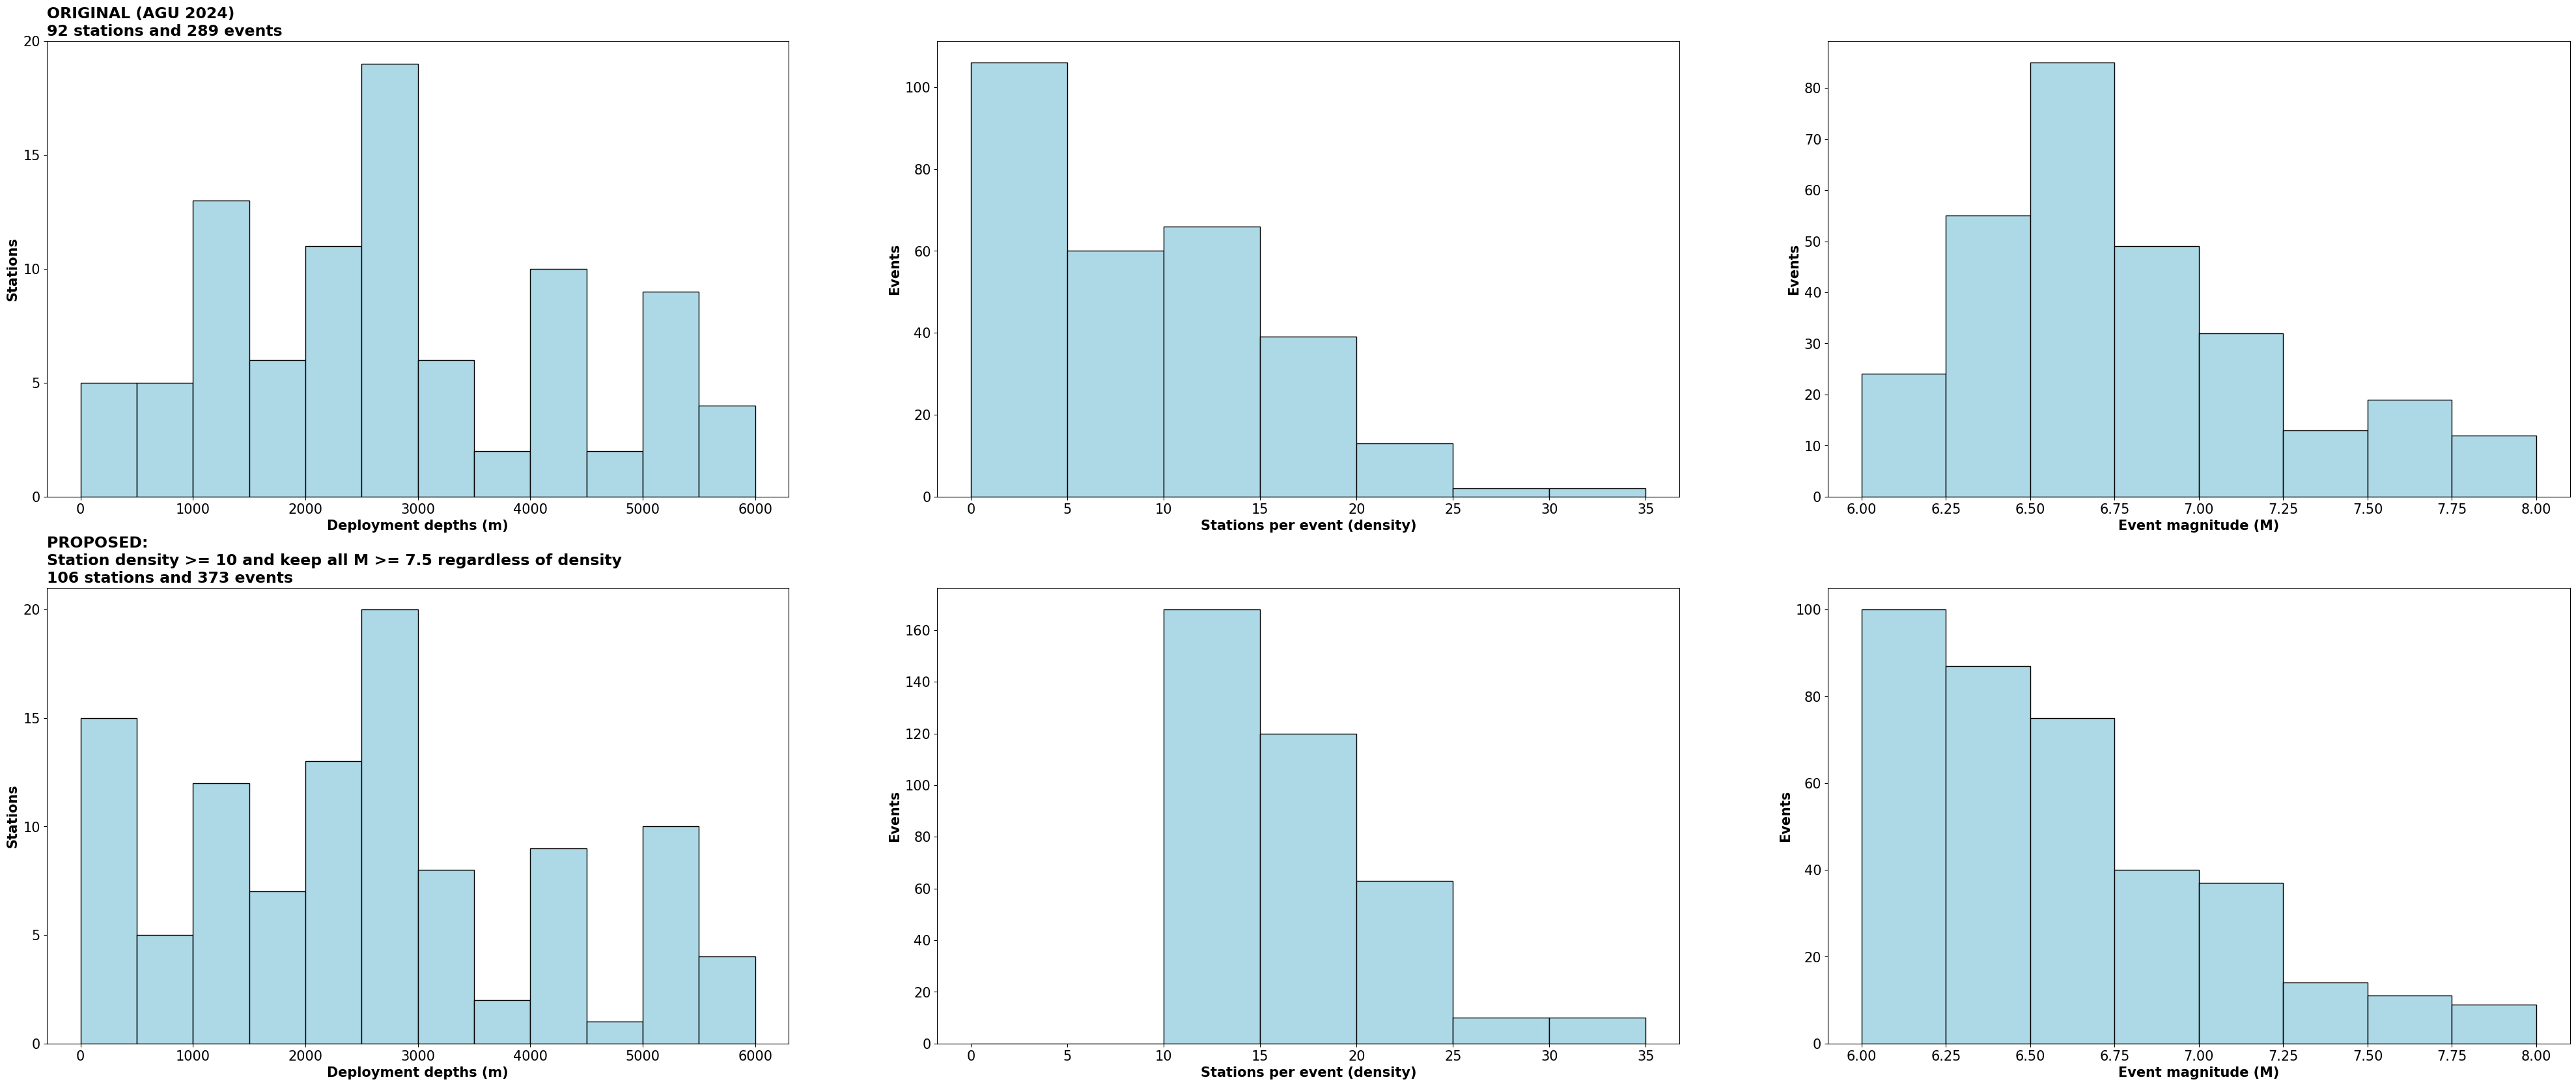

----------
In total these are the 18 new stations being added to the catalog, 8 from ENAM and 10 shallows from the Cascadia Initiative:


,StaName,Station,Network,Latitude,Longitude,Experiment,Environment,Pressure_Gauge,StaDepth,Start,End,Events,Good_Channels,Deployment,Inventory
7D.FS42D,7D.FS42D,FS42D,7D,40.715099,-124.463097,CASCADIA INITIATIVE,North Pacific,APG,95.0,2014-09-14,2015-10-05 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.G17B,7D.G17B,G17B,7D,41.283901,-124.344597,CASCADIA INITIATIVE,North Pacific,APG,123.0,2012-09-17,2013-07-01 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.FS08D,7D.FS08D,FS08D,7D,40.334702,-124.465302,CASCADIA INITIATIVE,North Pacific,DPG,132.0,2014-08-12,2015-09-15 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.J25A,7D.J25A,J25A,7D,44.472900,-124.621597,CASCADIA INITIATIVE,North Pacific,DPG,142.8,2011-10-21,2012-07-18 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.FS04D,7D.FS04D,FS04D,7D,40.252800,-124.505203,CASCADIA INITIATIVE,North Pacific,DPG,155.0,2014-08-12,2015-09-15 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.J09B,7D.J09B,J09B,7D,43.151001,-124.726997,CASCADIA INITIATIVE,North Pacific,DPG,252.0,2012-09-02,2013-06-21 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.J17D,7D.J17D,J17D,7D,43.787300,-124.613403,CASCADIA INITIATIVE,North Pacific,APG,285.0,2014-09-09,2015-10-03 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.J33C,7D.J33C,J33C,7D,45.106800,-124.570801,CASCADIA INITIATIVE,North Pacific,DPG,354.0,2013-08-22,2014-05-29 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.G25B,7D.G25B,G25B,7D,41.919899,-124.586098,CASCADIA INITIATIVE,North Pacific,APG,430.0,2012-09-18,2013-07-31 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None
7D.FC03D,7D.FC03D,FC03D,7D,44.813301,-124.738297,CASCADIA INITIATIVE,North Pacific,APG,432.0,2014-09-07,2015-10-02 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Station, Latitude, Longitude, Experi...",None


In [128]:
D = AttribDict()
D.original = AttribDict();D.updated = AttribDict();D.proposed = AttribDict()
D.original.cat=pd.read_pickle(dirs.Catalogs / 'sta_catalog_111524c.pkl')
D.proposed.cat = pd.read_pickle(dirs.Catalogs / 'Catalog_Test_DensityIncreased.ShalllowIncreased.pkl')


D.original.Events=lt.cat.unravel_cat(D.original.cat.copy())
D.proposed.Events=lt.cat.unravel_cat(D.proposed.cat.copy())
fig,axes=plt.subplots(ncols=3,nrows=2,figsize=(50,20))
bins=[np.arange(0,6500,500),np.arange(0,40,5),np.arange(6,8.25,.25)]
row_titles=['ORIGINAL (AGU 2024) \n','PROPOSED: \nStation density >= 10 and keep all M >= 7.5 regardless of density \n']
# row_titles=['Original','Updated']
for rt,row,ax in zip(row_titles,[D.original,D.proposed],axes):
    nev=len(row.Events)
    nsta=len(row.cat)

    a = ax[0]
    a.set_title(rt+f'{nsta} stations and {nev} events',loc='left',fontweight='bold',fontsize=17)
    # a.hist([len(evs) for evs in row.cat.Events],bins=bins[0],edgecolor='k',facecolor='lightblue')
    a.hist(row.cat.StaDepth,bins=bins[0],edgecolor='k',facecolor='lightblue')
    a.set_ylabel('Stations',fontweight='bold',fontsize=15)
    a.set_xlabel('Deployment depths (m)',fontweight='bold',fontsize=15)
    a.set_xticklabels(a.get_xticklabels(),fontsize=15)
    a.set_yticklabels(a.get_yticklabels(),fontsize=15)
    a.set_yticks(np.arange(0,25,5))
    a.set_yticklabels(np.arange(0,25,5))

    a = ax[1]
    a.hist([len(e.Stations) for e in row.Events],bins=bins[1],edgecolor='k',facecolor='lightblue')
    a.set_xlabel('Stations per event (density)',fontweight='bold',fontsize=15)
    a.set_ylabel('Events',fontweight='bold',fontsize=15)
    a.set_xticklabels(a.get_xticklabels(),fontsize=15)
    a.set_yticklabels(a.get_yticklabels(),fontsize=15)

    a = ax[2]
    a.hist([e.magnitudes[0].mag for e in row.Events],bins=bins[2],edgecolor='k',facecolor='lightblue')
    a.set_xlabel('Event magnitude (M)',fontweight='bold',fontsize=15)
    a.set_ylabel('Events',fontweight='bold',fontsize=15)
    a.set_xticklabels(a.get_xticklabels(),fontsize=15)
    a.set_yticklabels(a.get_yticklabels(),fontsize=15)
clear_output();plt.show()
new_stations = pd.DataFrame([s for s in D.proposed.cat.iloc if not np.any(D.original.cat.StaName.isin([s.StaName]))])
new_stations.sort_values('StaDepth',inplace=True)
print('-'*10)
print(f'In total these are the {len(new_stations)} new stations being added to the catalog, 8 from ENAM and 10 shallows from the Cascadia Initiative:')
display(new_stations)

# Side note on APG vs DPG stations in the data set:

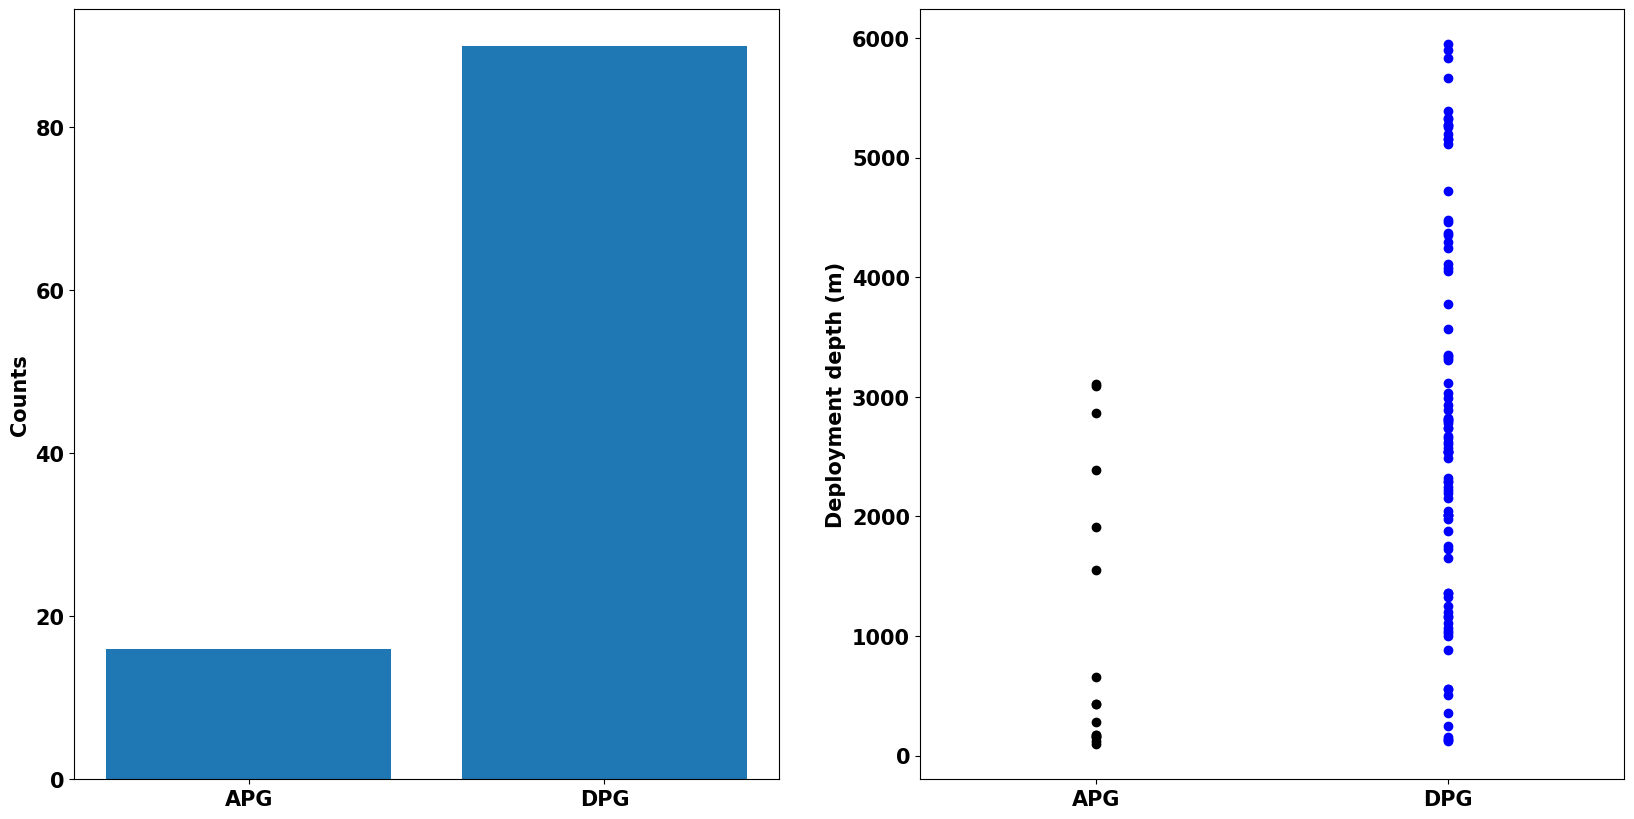

In [127]:
fig,axes=plt.subplots(ncols=2,nrows=1,figsize=(20,10))
axes[0].bar([0,1],[sum(D.proposed.cat.Pressure_Gauge=='APG'),sum(D.proposed.cat.Pressure_Gauge=='DPG')])
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['APG','DPG'],fontweight='bold',fontsize=15)
axes[0].set_ylabel('Counts',fontweight='bold',fontsize=15)
axes[0].set_yticklabels(axes[0].get_yticklabels(),fontweight='bold',fontsize=15)
_=[axes[1].scatter(.5,s.StaDepth,c='k') for s in d.iloc if s.Pressure_Gauge=='APG']
_=[axes[1].scatter(1.5,s.StaDepth,c='b') for s in d.iloc if s.Pressure_Gauge=='DPG']
_=axes[1].set_xticks([.5,1.5])
_=axes[1].set_xticklabels(['APG','DPG'],fontweight='bold',fontsize=15)
_=axes[1].set_xlim(0,2)
_=axes[1].set_ylabel('Deployment depth (m)',fontweight='bold',fontsize=15)
_=axes[1].set_yticklabels(axes[1].get_yticklabels(),fontweight='bold',fontsize=15)